In [5]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from wordcloud import WordCloud

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)


In [6]:
# Update the path if required
df = pd.read_csv("data/SMSSpamCollection", sep="\t", header=None, names=["label","message"])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


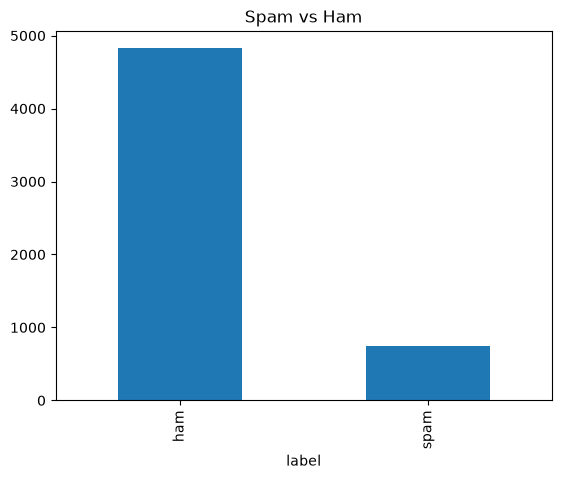

In [7]:
counts = df['label'].value_counts()
percent = round(df['label'].value_counts(normalize=True)*100,2)

print(counts)
print(percent)

counts.plot(kind='bar', title='Spam vs Ham')
plt.show()

In [8]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["message"].apply(preprocess)
df.head()


,label,message,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives


In [9]:
X = df["clean_text"]
y = df["label"]

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)


Accuracy: 0.9641255605381166
Precision: 1.0
Recall: 0.7315436241610739
F1: 0.8449612403100775
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



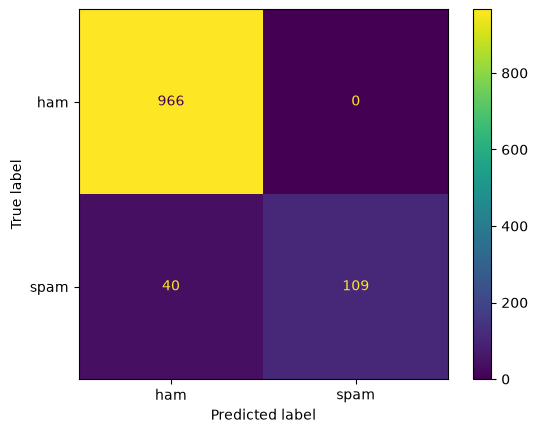

In [10]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, nb_pred, pos_label="spam"))
print("F1:", f1_score(y_test, nb_pred, pos_label="spam"))
print(classification_report(y_test, nb_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, nb_pred), display_labels=["ham","spam"]).plot()
plt.show()


Accuracy: 0.95695067264574
Precision: 1.0
Recall: 0.6778523489932886
F1: 0.808
              precision    recall  f1-score   support

         ham       0.95      1.00      0.98       966
        spam       1.00      0.68      0.81       149

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



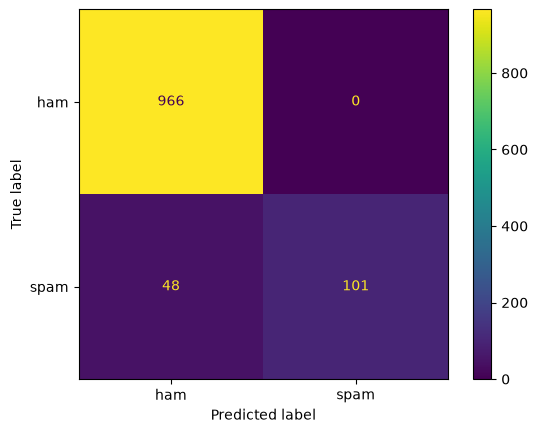

In [11]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, lr_pred, pos_label="spam"))
print("F1:", f1_score(y_test, lr_pred, pos_label="spam"))
print(classification_report(y_test, lr_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred), display_labels=["ham","spam"]).plot()
plt.show()


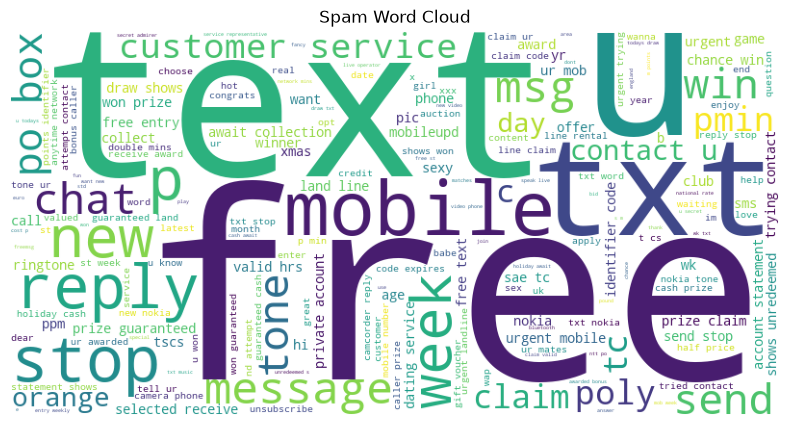

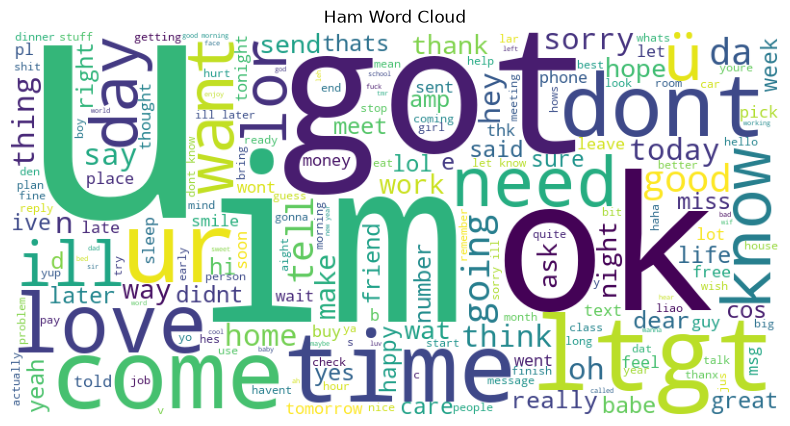

In [12]:
spam_text = " ".join(df[df.label=="spam"]["clean_text"])
ham_text = " ".join(df[df.label=="ham"]["clean_text"])

plt.figure(figsize=(12,5))
plt.imshow(WordCloud(width=800,height=400,background_color="white").generate(spam_text))
plt.axis("off")
plt.title("Spam Word Cloud")
plt.show()

plt.figure(figsize=(12,5))
plt.imshow(WordCloud(width=800,height=400,background_color="white").generate(ham_text))
plt.axis("off")
plt.title("Ham Word Cloud")
plt.show()
